In [40]:
import re

def parse_log(file_path):
    epochs, losses = [], []
    eval_epochs, train_acc, valid_acc, test_acc = [], [], [], []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            # ===== Loss =====
            m = re.search(r"Epoch:\s*(\d+),\s*Loss:\s*([\d\.]+)", line)
            if m:
                epochs.append(int(m.group(1)))
                losses.append(float(m.group(2)))

            # ===== Accuracy (handle ALL formats) =====
            m2 = re.search(
                r"Epoch:\s*(\d+).*Train:\s*([\d\.]+)%?,\s*(Val|Valid):\s*([\d\.]+)%?,\s*Test:\s*([\d\.]+)%?",
                line
            )
            if m2:
                eval_epochs.append(int(m2.group(1)))

                train = float(m2.group(2))
                valid = float(m2.group(4))
                test = float(m2.group(5))

                # Nếu là dạng % thì convert về [0,1]
                if train > 1:
                    train /= 100
                    valid /= 100
                    test /= 100

                train_acc.append(train)
                valid_acc.append(valid)
                test_acc.append(test)

    return epochs, losses, eval_epochs, train_acc, valid_acc, test_acc

In [41]:
import matplotlib.pyplot as plt

def shorten_dataset(name):
    m = re.search(r"ogbn-([A-Za-z]+)_no(\d+)", name)
    if m:
        return f"{m.group(1)}_no_{m.group(2)}"
    return name

def plot_training(log_path, model_name, dataset_name):
    epochs, losses, eval_epochs, train_acc, valid_acc, test_acc = parse_log(log_path)

    title_prefix = f"{model_name} | {shorten_dataset(dataset_name)}"

    # ===== Loss =====
    plt.figure()
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.grid()

    # ===== Accuracy =====
    plt.figure()
    plt.plot(eval_epochs, train_acc, label="Train")
    plt.plot(eval_epochs, valid_acc, label="Valid")
    plt.plot(eval_epochs, test_acc, label="Test")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

In [42]:
def plot_training_save(log_path):
    epochs, losses, eval_epochs, train_acc, valid_acc, test_acc = parse_log(log_path)

    # Loss
    plt.figure()
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.savefig("loss.png")

    # Accuracy
    plt.figure()
    plt.plot(eval_epochs, train_acc, label="Train")
    plt.plot(eval_epochs, valid_acc, label="Valid")
    plt.plot(eval_epochs, test_acc, label="Test")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy")
    plt.legend()
    plt.grid()
    plt.savefig("accuracy.png")

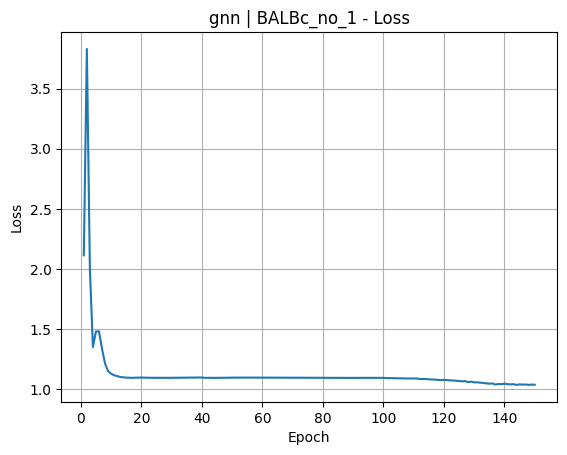

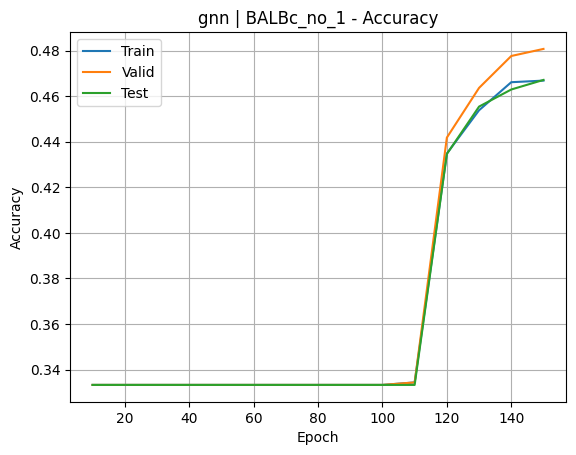

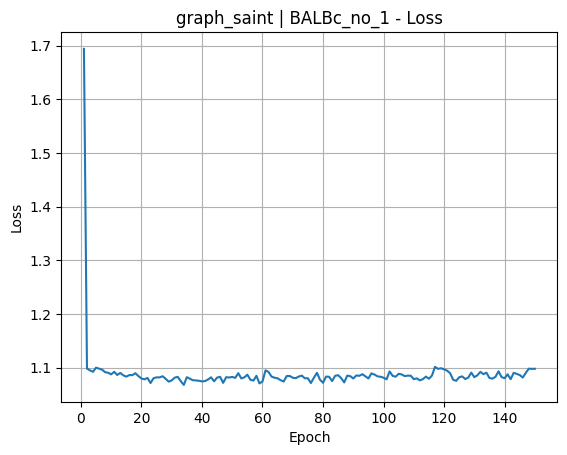

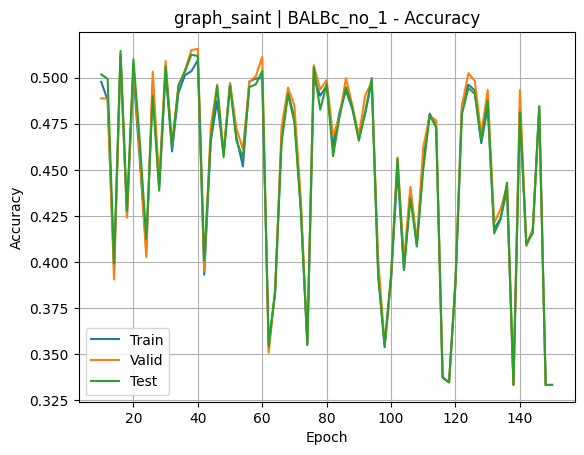

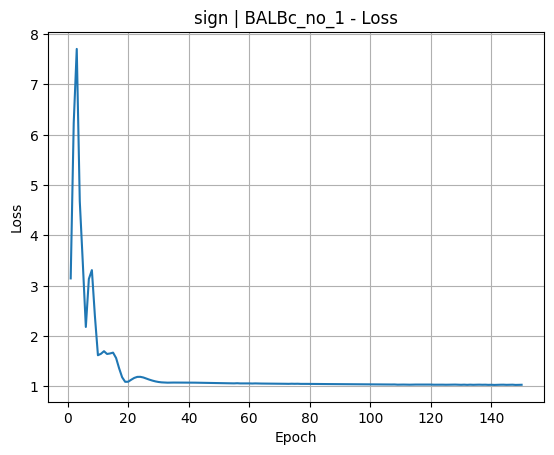

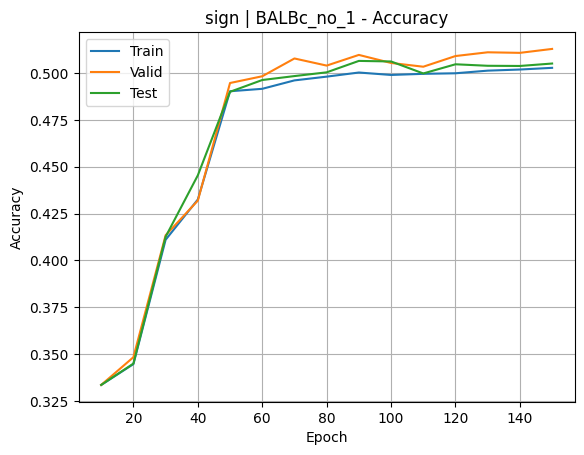

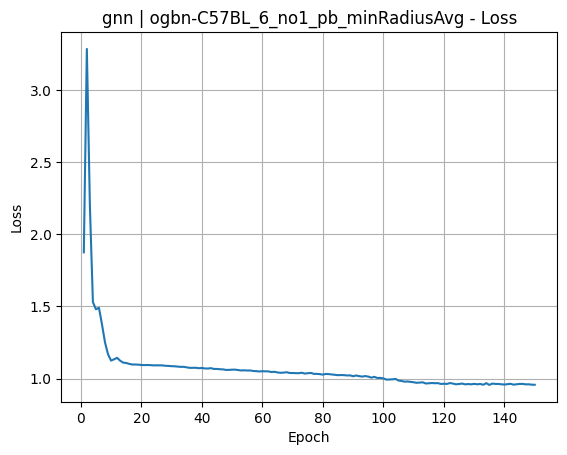

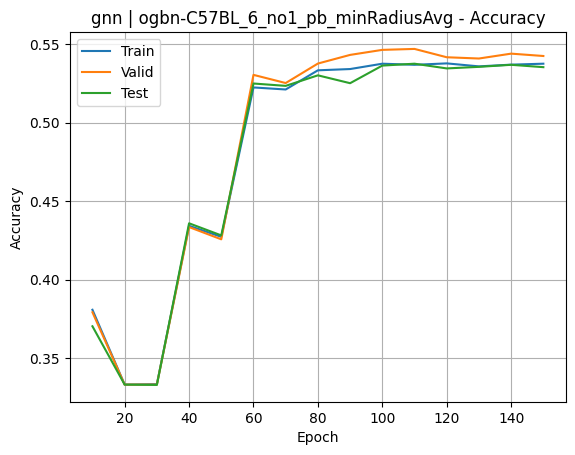

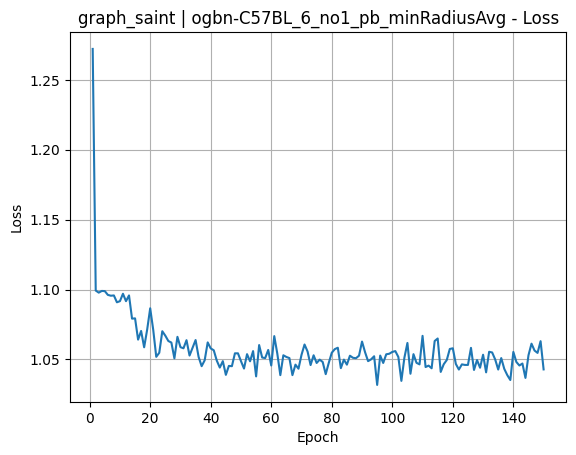

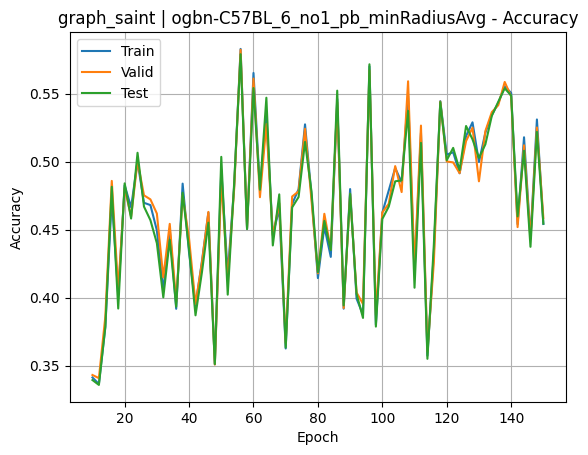

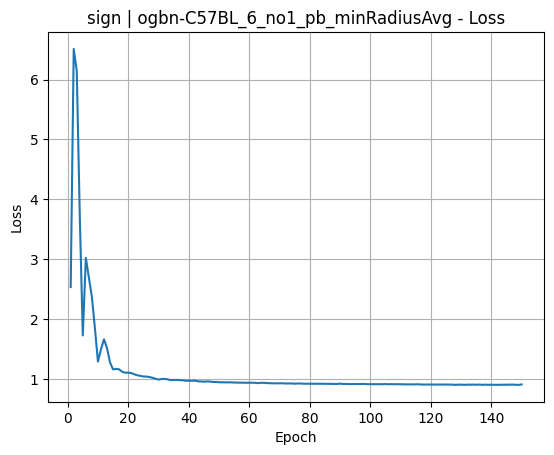

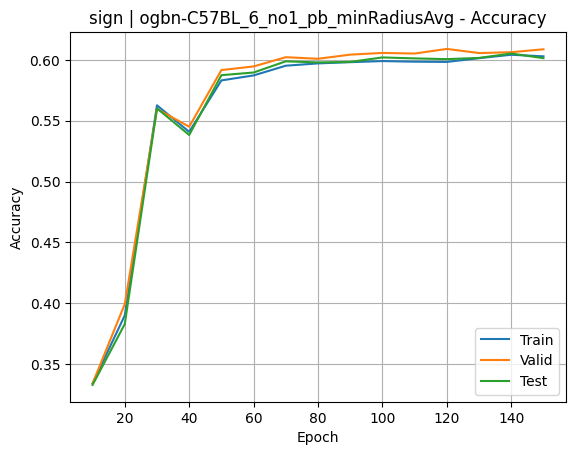

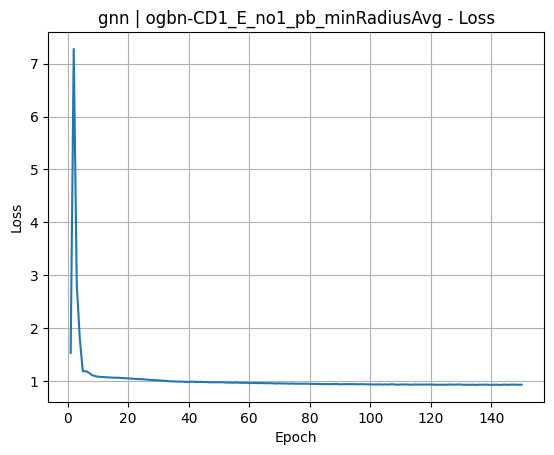

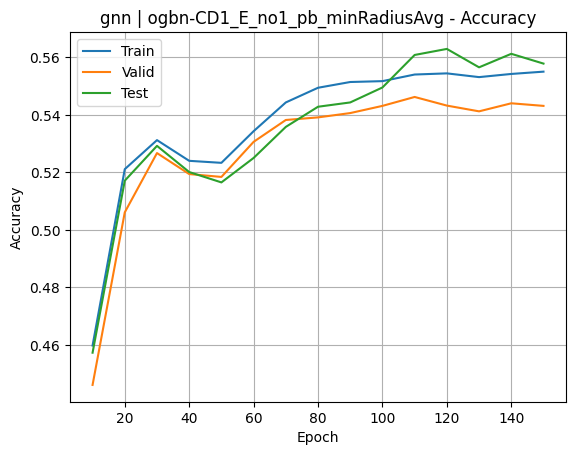

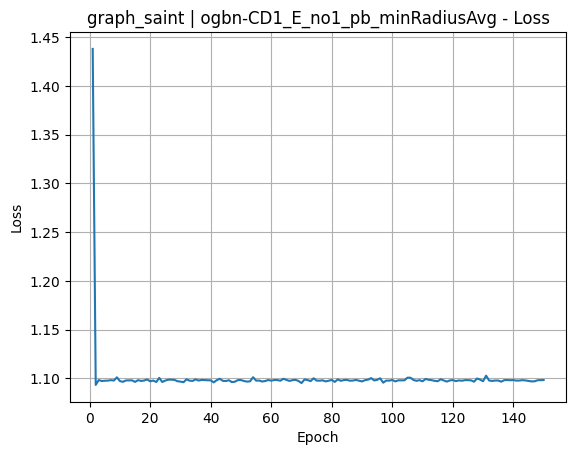

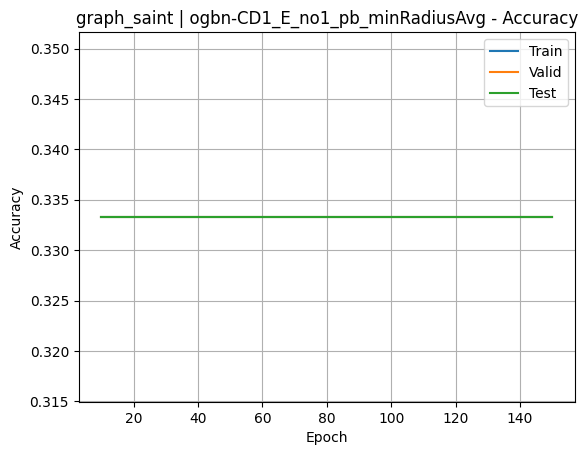

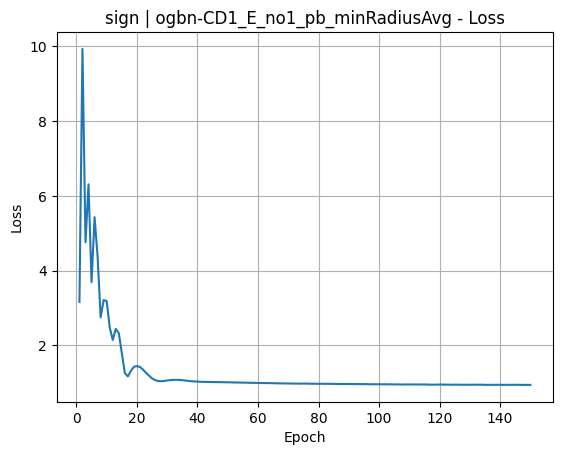

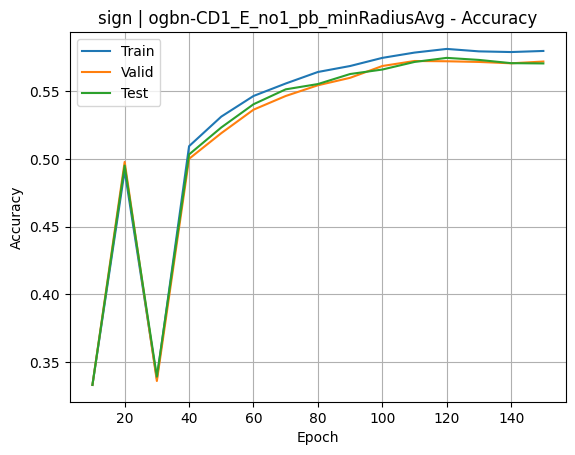

In [43]:
datasets = ["ogbn-BALBc_no1_pb_minRadiusAvg", "ogbn-C57BL_6_no1_pb_minRadiusAvg",
           "ogbn-CD1_E_no1_pb_minRadiusAvg"]

for dataset in datasets:
    for model in ["gnn", "graph_saint", "sign"]:
        plot_training(
            log_path=f"./{model}/{dataset}_lr0.025_ch32_layers3.log",
            model_name=model,
            dataset_name=dataset
        )

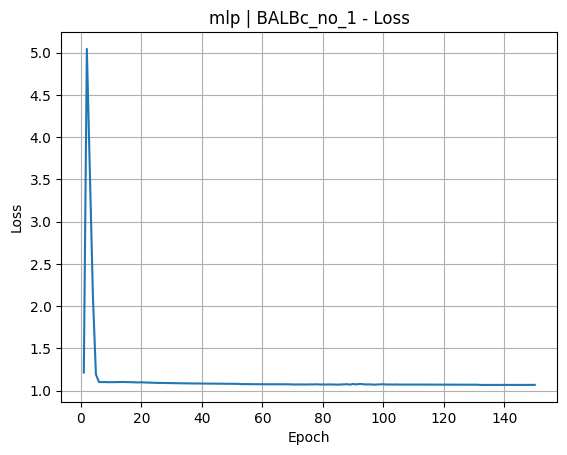

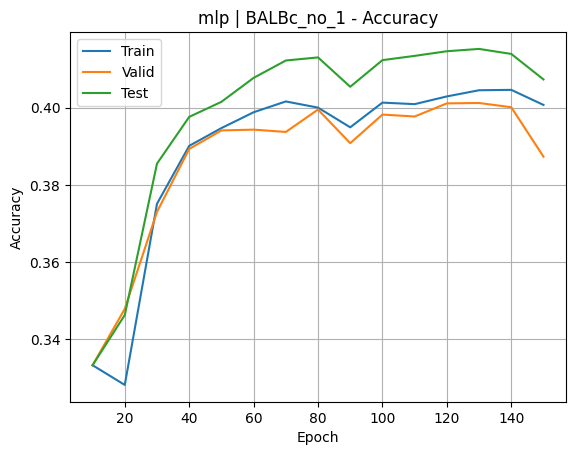

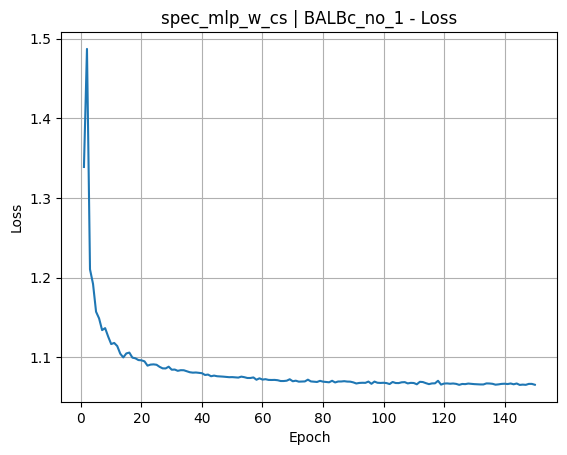

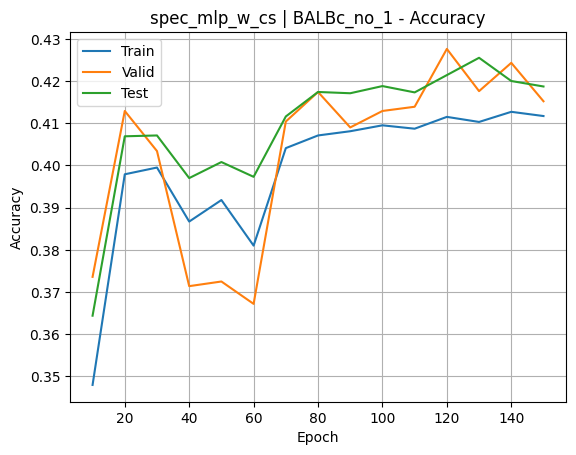

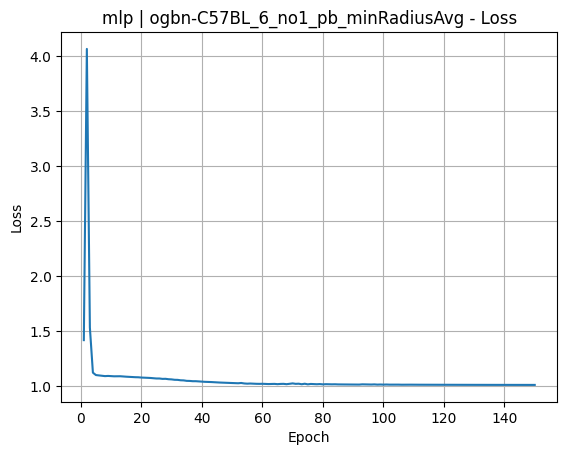

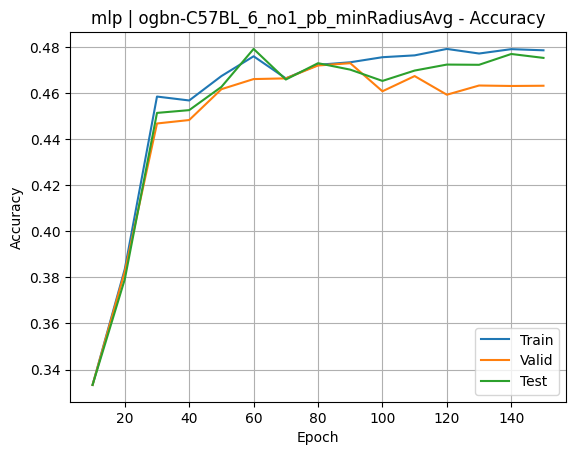

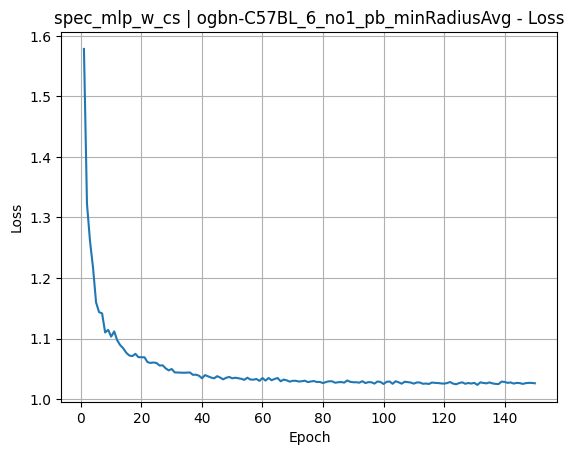

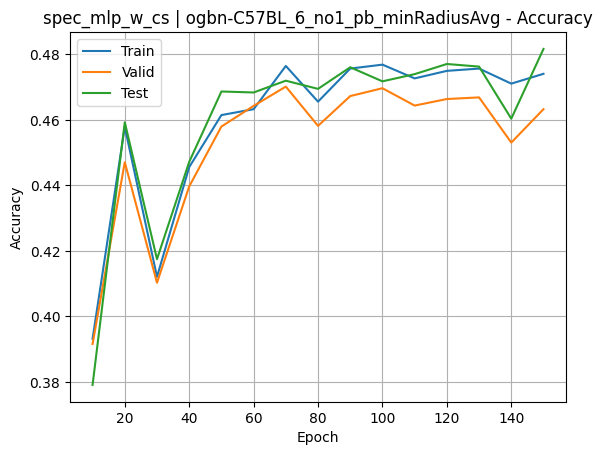

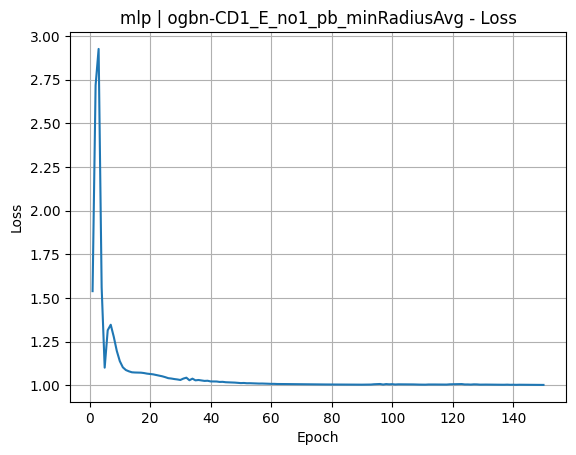

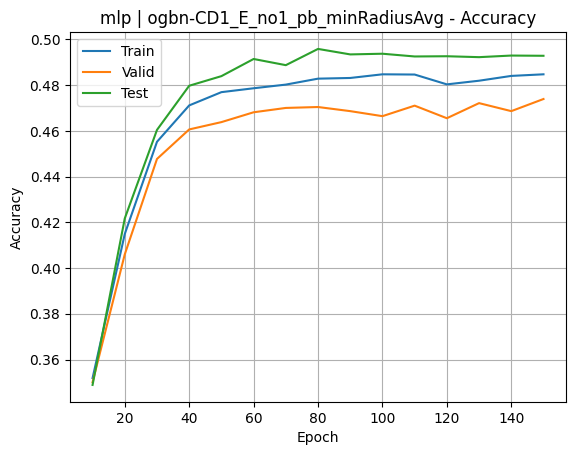

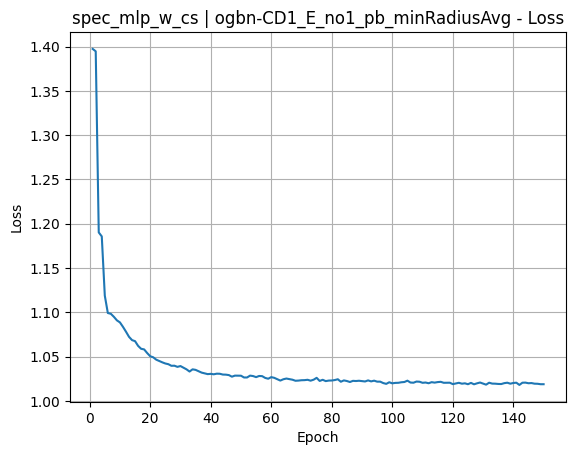

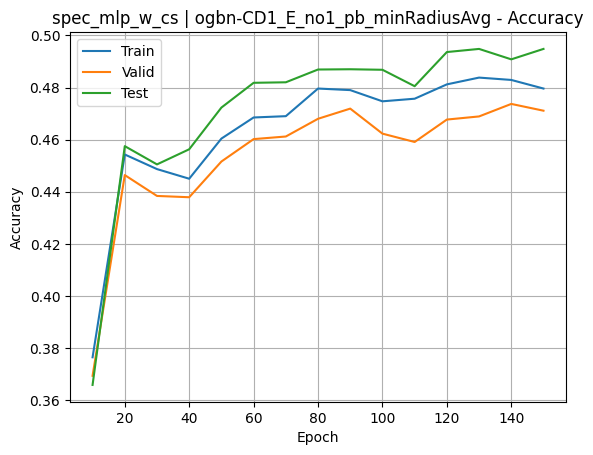

In [44]:
for dataset in datasets:
    for model in ["mlp", "spec_mlp_w_cs"]:
        plot_training(
            log_path=f"./{model}/{dataset}_lr0.025_ch64_layers3.log",
            model_name=model,
            dataset_name=dataset
        )